# Exploratory Data Analysis — Raw Feedback Dataset

Load libraries and datasets.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import re
import os
from itertools import combinations
from collections import Counter
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

raw_df = pd.read_csv("../data/raw/raw_feedback.csv")
absa_df = pd.read_csv("../data/raw/absa_dataset.csv")

Define color palette and output directory.

In [2]:
COLORS = {
    'Positive': '#2ecc71',
    'Negative': '#e74c3c',
    'Neutral' : '#3498db'
}

OUTPUT_DIR = '../outputs/eda'
os.makedirs(OUTPUT_DIR, exist_ok=True)

Add derived columns and inspect dataset shapes.

In [3]:
raw_df['word_count'] = raw_df['feedback_text'].str.split().str.len()
raw_df['char_count'] = raw_df['feedback_text'].str.len()

print('Raw feedback shape:', raw_df.shape)
print('ABSA dataset shape:', absa_df.shape)

Raw feedback shape: (6750, 7)
ABSA dataset shape: (13100, 4)


Check for missing values in both datasets.

In [4]:
print('raw_feedback missing values:')
print(raw_df.isnull().sum())
print('\nabsa_dataset missing values:')
print(absa_df.isnull().sum())

raw_feedback missing values:
feedback_id      0
feedback_text    0
aspects          0
sentiments       0
num_aspects      0
word_count       0
char_count       0
dtype: int64

absa_dataset missing values:
feedback_id      0
feedback_text    0
aspect           0
sentiment        0
dtype: int64


Compute high-level dataset statistics.

In [5]:
total_feedbacks   = len(raw_df)
total_aspect_rows = len(absa_df)
unique_aspects    = absa_df['aspect'].nunique()
avg_aspects       = raw_df['num_aspects'].mean()
multi_aspect_pct  = (raw_df['num_aspects'] > 1).sum() / total_feedbacks * 100

print(f'Total feedback entries     : {total_feedbacks:,}')
print(f'Total aspect-level rows    : {total_aspect_rows:,}')
print(f'Unique aspect categories   : {unique_aspects}')
print(f'Avg aspects per feedback   : {avg_aspects:.2f}')
print(f'Multi-aspect feedbacks     : {multi_aspect_pct:.1f}%')

Total feedback entries     : 6,750
Total aspect-level rows    : 13,100
Unique aspect categories   : 22
Avg aspects per feedback   : 1.94
Multi-aspect feedbacks     : 57.7%


Plot aspect frequency distribution.

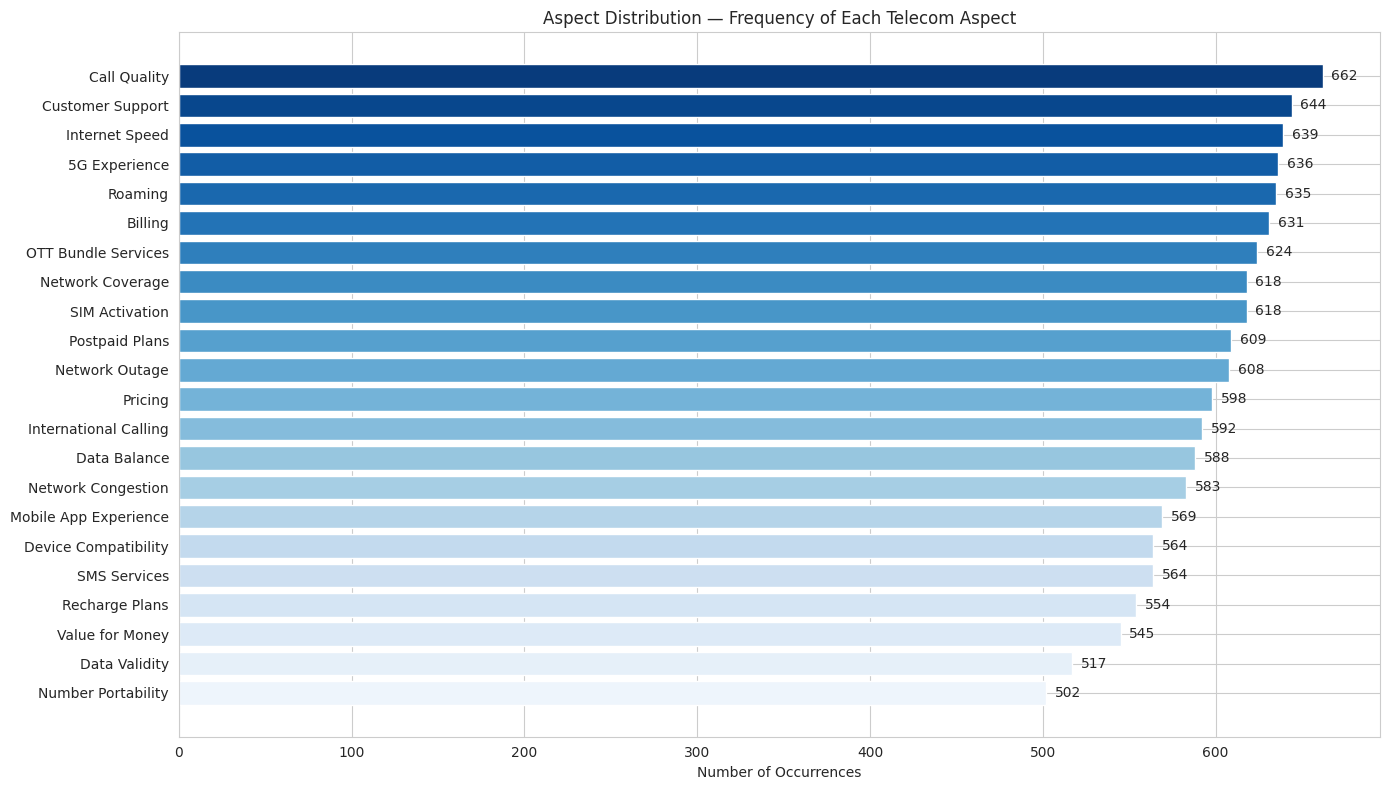

Most frequent aspect  : Call Quality (662)
Least frequent aspect : Number Portability (502)
Spread (max - min)    : 160


In [6]:
aspect_counts = absa_df['aspect'].value_counts().reset_index()
aspect_counts.columns = ['aspect', 'count']

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(
    aspect_counts['aspect'],
    aspect_counts['count'],
    color=sns.color_palette('Blues_r', len(aspect_counts))
)

for bar, val in zip(bars, aspect_counts['count']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)

ax.set_xlabel('Number of Occurrences')
ax.set_title('Aspect Distribution \u2014 Frequency of Each Telecom Aspect')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_aspect_distribution.png', bbox_inches='tight')
plt.show()

print(f'Most frequent aspect  : {aspect_counts.iloc[0]["aspect"]} ({aspect_counts.iloc[0]["count"]})')
print(f'Least frequent aspect : {aspect_counts.iloc[-1]["aspect"]} ({aspect_counts.iloc[-1]["count"]})')
print(f'Spread (max - min)    : {aspect_counts.iloc[0]["count"] - aspect_counts.iloc[-1]["count"]}')

Visualize overall sentiment distribution (bar + pie).

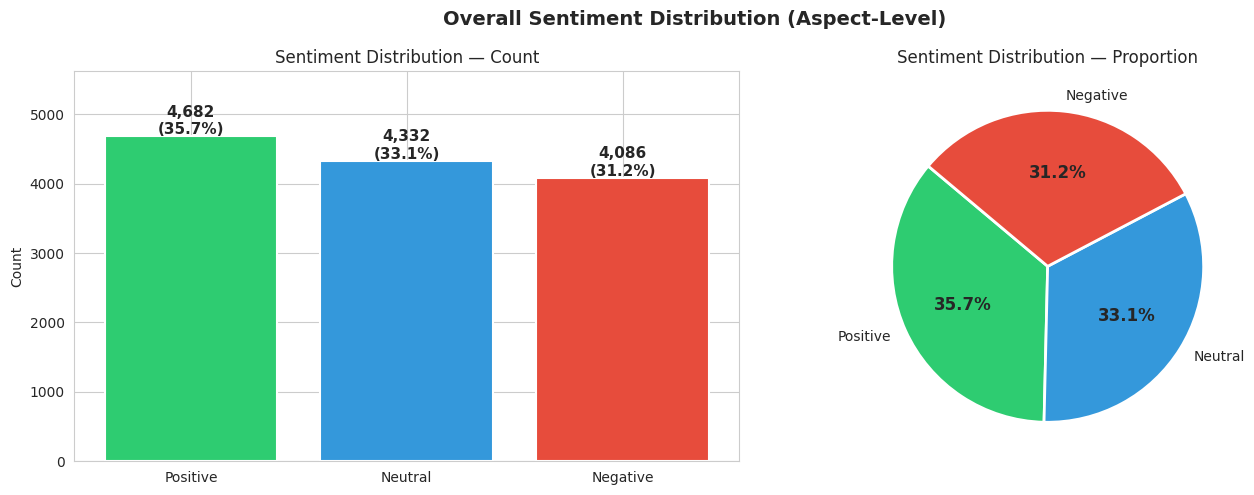

In [7]:
sentiment_counts = absa_df['sentiment'].value_counts()
sentiment_pct    = absa_df['sentiment'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = [COLORS[s] for s in sentiment_counts.index]
bars = axes[0].bar(
    sentiment_counts.index,
    sentiment_counts.values,
    color=colors,
    edgecolor='white',
    linewidth=1.5
)
for bar, val, pct in zip(bars, sentiment_counts.values, sentiment_pct.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 30,
        f'{val:,}\n({pct:.1f}%)',
        ha='center', fontsize=11, fontweight='bold'
    )
axes[0].set_title('Sentiment Distribution \u2014 Count')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(sentiment_counts.values) * 1.2)

wedges, texts, autotexts = axes[1].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for text in autotexts:
    text.set_fontsize(12)
    text.set_fontweight('bold')
axes[1].set_title('Sentiment Distribution \u2014 Proportion')

plt.suptitle('Overall Sentiment Distribution (Aspect-Level)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_sentiment_distribution.png', bbox_inches='tight')
plt.show()

Compute aspect × sentiment crosstab.

In [8]:
aspect_sentiment = pd.crosstab(
    absa_df['aspect'],
    absa_df['sentiment']
)

aspect_sentiment_pct = pd.crosstab(
    absa_df['aspect'],
    absa_df['sentiment'],
    normalize='index'
) * 100

aspect_sentiment_pct.round(1)

sentiment,Negative,Neutral,Positive
aspect,,,
5G Experience,25.8,37.3,36.9
Billing,33.1,31.5,35.3
Call Quality,31.6,34.3,34.1
Customer Support,31.2,34.3,34.5
Data Balance,26.0,31.0,43.0
Data Validity,31.3,33.3,35.4
Device Compatibility,23.8,31.2,45.0
International Calling,35.0,30.1,35.0
Internet Speed,30.0,34.6,35.4


Heatmap of aspect-wise sentiment counts.

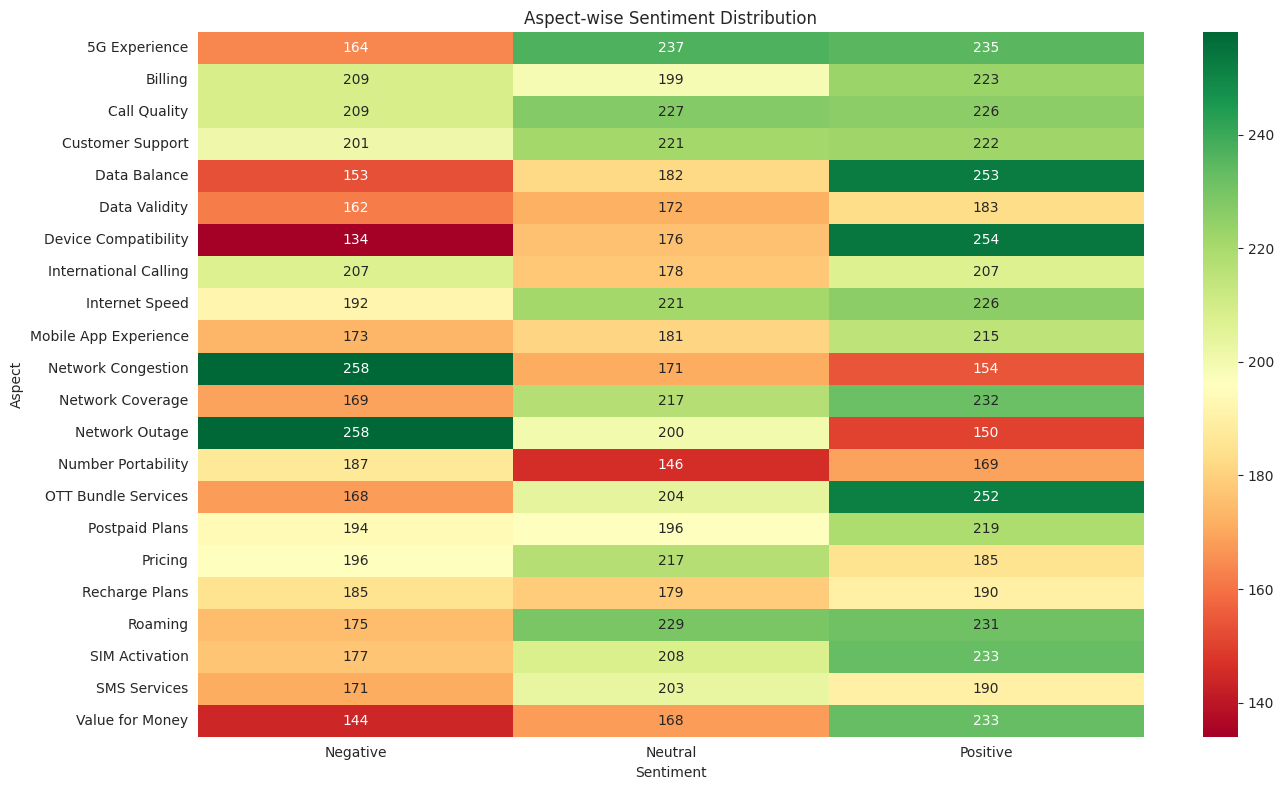

In [9]:
plt.figure(figsize=(14,8))

sns.heatmap(
    aspect_sentiment,
    annot=True,
    fmt='d',
    cmap='RdYlGn'
)

plt.title('Aspect-wise Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Aspect')
plt.tight_layout()
plt.show()

Stacked bar chart of sentiment composition by aspect (%).

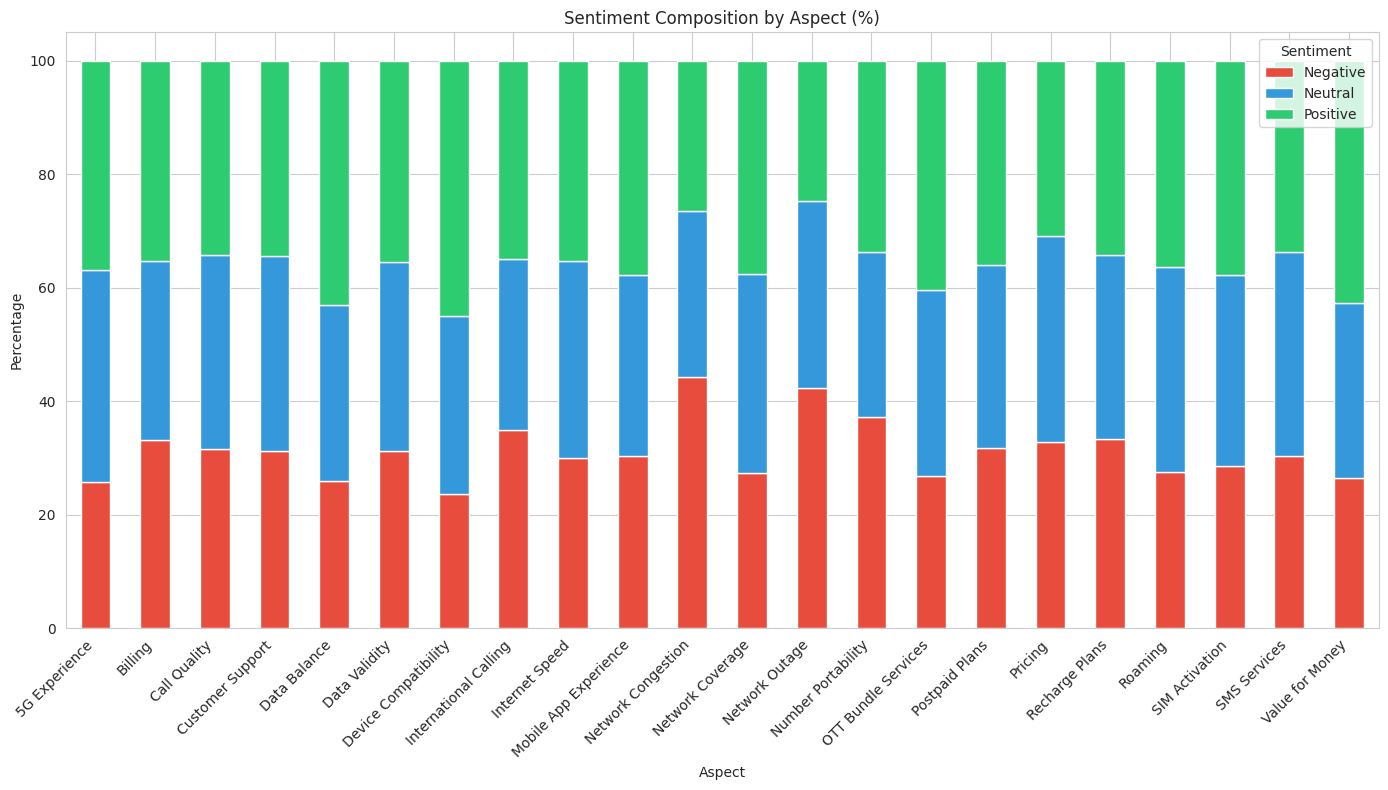

In [10]:
aspect_sentiment_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(14,8),
    color=['#e74c3c', '#3498db', '#2ecc71']
)

plt.title('Sentiment Composition by Aspect (%)')
plt.ylabel('Percentage')
plt.xlabel('Aspect')
plt.legend(title='Sentiment')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Assess class imbalance for aspects and sentiment.

In [11]:
print("Aspect count statistics:")
print(aspect_counts['count'].describe())

imbalance_ratio = aspect_counts['count'].max() / aspect_counts['count'].min()
print(f"\nAspect imbalance ratio: {imbalance_ratio:.2f}")

sentiment_ratio = sentiment_counts.max() / sentiment_counts.min()
print(f"Sentiment imbalance ratio: {sentiment_ratio:.2f}")

Aspect count statistics:
count     22.000000
mean     595.454545
std       42.193124
min      502.000000
25%      565.250000
50%      603.000000
75%      629.250000
max      662.000000
Name: count, dtype: float64

Aspect imbalance ratio: 1.32
Sentiment imbalance ratio: 1.15


Descriptive statistics of feedback text length.

In [12]:
raw_df[['word_count', 'char_count']].describe()

,word_count,char_count
count,6750.000000,6750.000000
mean,15.774667,101.476741
std,7.524743,47.743316
min,4.000000,27.000000
25%,9.000000,60.000000
50%,14.000000,91.000000
75%,22.000000,141.000000
max,40.000000,246.000000


Distribution of feedback length by word count.

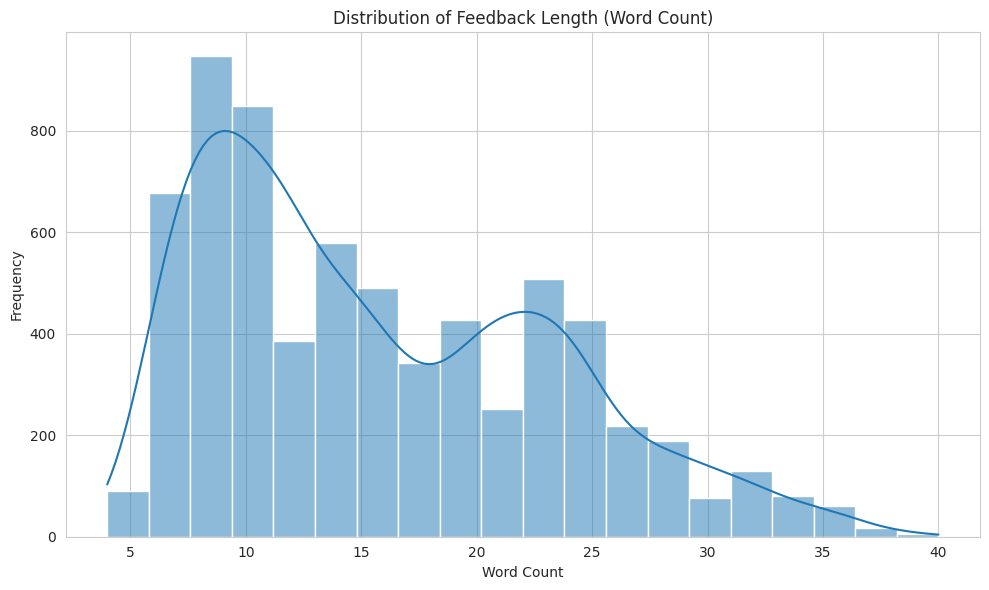

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(
    raw_df['word_count'],
    bins=20,
    kde=True
)

plt.title('Distribution of Feedback Length (Word Count)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Distribution of feedback length by character count.

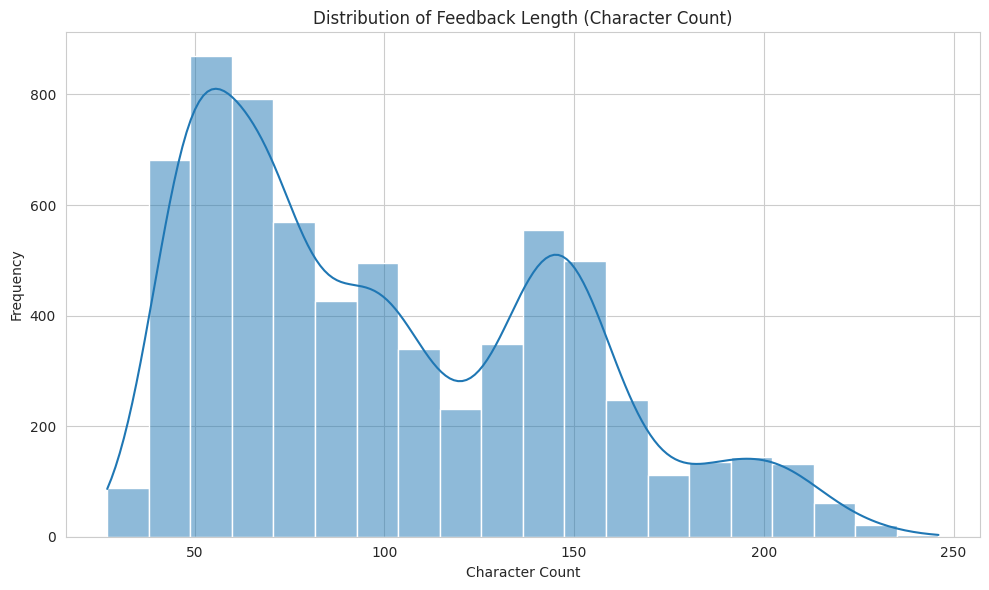

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(
    raw_df['char_count'],
    bins=20,
    kde=True
)

plt.title('Distribution of Feedback Length (Character Count)')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Word count statistics grouped by sentiment.

In [15]:
absa_df['word_count'] = absa_df['feedback_text'].str.split().str.len()

absa_df.groupby('sentiment')['word_count'].describe()

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
Negative,4086.0,17.899657,7.321451,4.0,12.0,18.0,23.0,40.0
Neutral,4332.0,20.504617,8.095210,4.0,13.0,21.0,26.0,39.0
Positive,4682.0,17.348996,7.119719,4.0,12.0,17.0,22.0,40.0


Basic text cleaning for word cloud generation.

In [16]:
import re

def basic_clean(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

absa_df["clean_text"] = absa_df["feedback_text"].apply(basic_clean)

Remove standard English stopwords from cleaned text.

In [17]:
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))

absa_df["clean_text"] = absa_df["clean_text"].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stop_words
    )
)

Generate an overall word cloud from all feedback text.

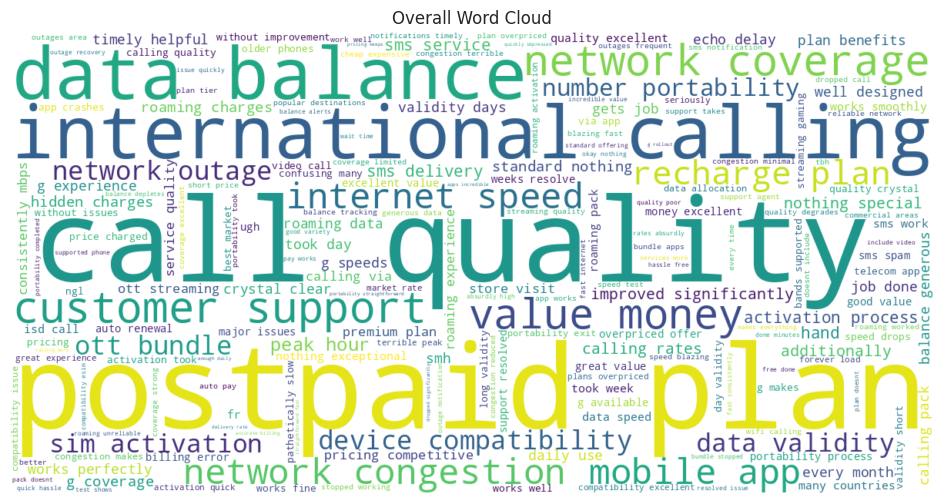

In [18]:
all_text = " ".join(absa_df["clean_text"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(all_text)

plt.figure(figsize=(14,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Overall Word Cloud")
plt.show()

Remove domain-specific stopwords to surface more interesting terms.

In [19]:
custom_stopwords = {
    'call', 'quality', 'data', 'balance', 'customer', 'support',
    'network', 'coverage', 'speed', 'billing', 'pricing',
    'recharge', 'plans', 'plan', 'service', 'services',
    'mobile', 'app', 'international', 'calling',
    'sim', 'activation', 'money', 'value',
    'g', 'number', 'postpaid', 'ott', 'sms',
    'roaming', 'portability', 'validity',
    'bundle', 'device', 'internet'
}

all_stopwords = stop_words.union(custom_stopwords)

absa_df["cloud_text"] = absa_df["clean_text"].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in all_stopwords
    )
)

Top 20 most frequent terms after domain stopword removal.

In [20]:
from collections import Counter

words = " ".join(absa_df["cloud_text"]).split()

top_words = Counter(words).most_common(20)

top_words_df = pd.DataFrame(
    top_words,
    columns=["word", "frequency"]
)

top_words_df

,word,frequency
0,standard,1803
1,works,1425
2,congestion,1320
3,outage,999
4,compatibility,907
5,experience,906
6,nothing,895
7,okay,873
8,good,839
9,excellent,836


Bar chart of top 20 terms.

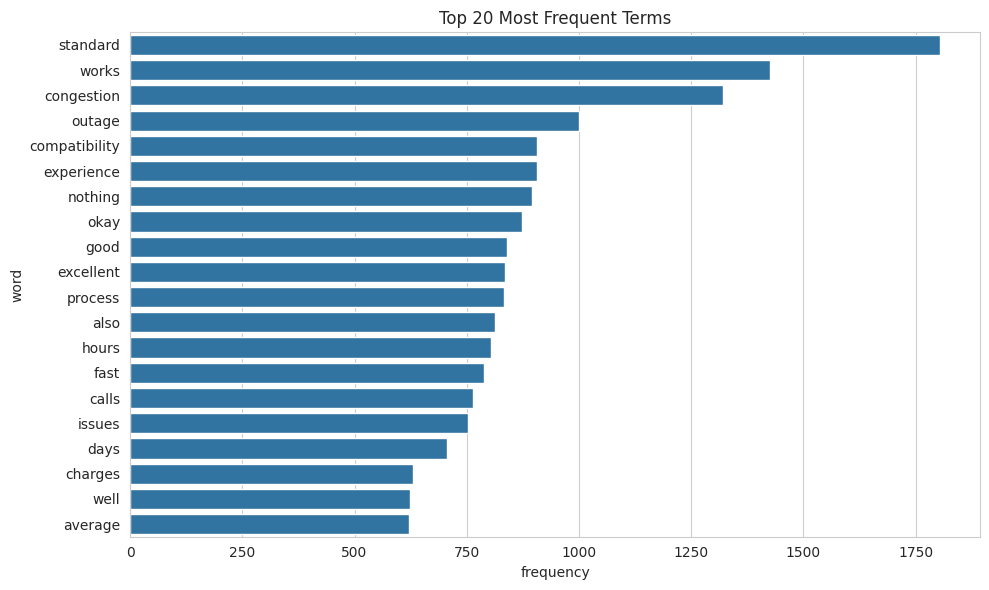

In [21]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_words_df,
    x="frequency",
    y="word"
)

plt.title("Top 20 Most Frequent Terms")
plt.tight_layout()
plt.show()